<a href="https://colab.research.google.com/github/abbynam/neur-265/blob/main/homework/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Abby Nam
*NEUR265*

**4/2/26**

In [1]:
# import modules

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
# import csvs as numpy arrays

fear_traces = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv', delimiter=',')
extinction_predictors = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv', delimiter = ',')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter = ',')
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter = ',')

In [59]:
# make new variables

conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10457:, :]

In [60]:
# print size of new arrays

print(np.size(conditioning_traces))
print(np.size(extinction_traces))

658854
895293


In [61]:
# make time variables for both sessions

print(np.shape(conditioning_traces))
print(np.shape(extinction_traces))

time_conditioning = np.linspace(0, 10458/15, 10458)
time_extinction = np.linspace(0, 14211/15, 14211)

(10458, 63)
(14211, 63)


63 ROIs were imaged during these sessions. The conditioning session was 697.2 seconds (11.62 minutes) long. The extinction session was 947.4 seconds (15.79 minutes) long.

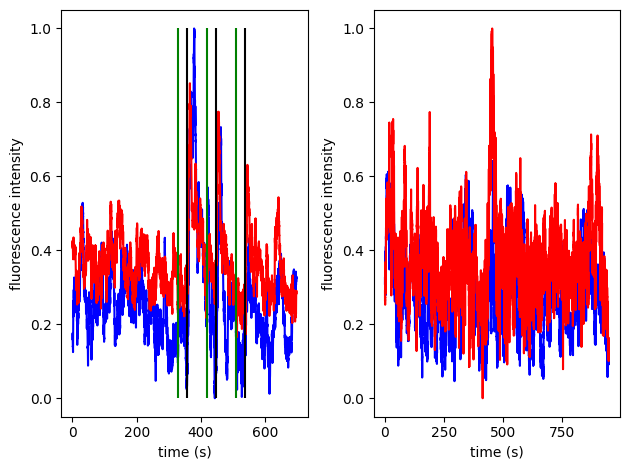

In [62]:
# create subplots

fig, ax = plt.subplots(1, 2)

# conditioning session (1st subplot)
ax[0].plot(time_conditioning, conditioning_traces[:, 0], color = 'blue')
ax[0].plot(time_conditioning, conditioning_traces[:, 1], color = 'red')

# extinction session (2nd subplot)
ax[1].plot(time_extinction, extinction_traces[:, 0], color = 'blue')
ax[1].plot(time_extinction, extinction_traces[:, 1], color = 'red')

# add vertical lines on first subplot
ax[0].vlines(shock_index, 0, 1, color = 'black')
ax[0].vlines(tone_index, 0, 1, color = 'green')

# label axes
ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('fluorescence intensity')

ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('fluorescence intensity')

plt.tight_layout()


During the conditioning session for the first ROI, fluorescence intensity dramatically increased immediately following a shock, but not really after a tone. However, the sharpest increase in fluorescence intensity occurred the first time the shock was presented, and with each subsequent shock the maximum fluorescence intensity was slightly lower. The same pattern was largely observed for the second ROI, with slightly less dramatic decreases in intensity each time the shock was presented compared to the first ROI.

During the extinction session for the first ROI, fluorescence intensity was higher overall than fluorescence intensity at baseline during the conditioning session (before any shocks were administered). The same pattern was observed for the second ROI, though with larger peaks in fluorescence intensity. Interestingly at ~450s during the extinction session, the second ROI's fluorescence intensity is higher than it was at any point during the conditioning session.

In [68]:
# make predictors conditioning variable and recreate shock and tone arrays

from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0


predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
predictors_conditioning['shock onset'] = shock_array

In [74]:
# run model for each ROI in conditioning traces

r_model_conditioning = np.zeros(63)

for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model3 = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_conditioning[i] = r3.statistic

In [75]:
# run model for each ROI in extinction traces

r_model_extinction = np.zeros(63)

for i in range(63):
  trace_temp = extinction_traces[:,i]
  model3 = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_extinction[i] = r3.statistic

In [76]:
# correlate variables

pearsonr(r_model_conditioning, r_model_extinction)

PearsonRResult(statistic=np.float64(0.014135850678388082), pvalue=np.float64(0.9124422932886772))

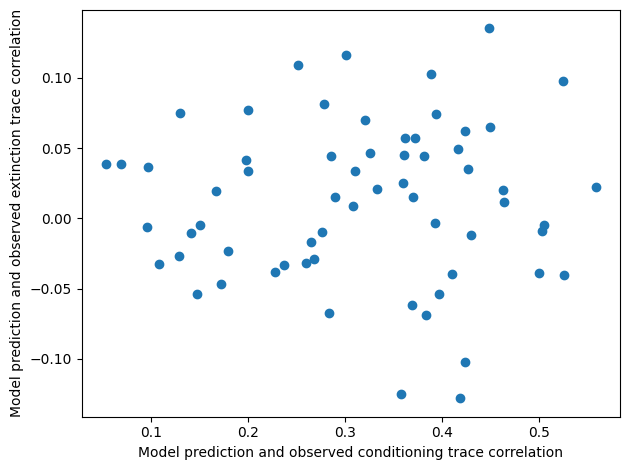

In [77]:
# make scatterplot

plt.scatter(r_model_conditioning, r_model_extinction)
plt.xlabel('Model prediction and observed conditioning trace correlation')
plt.ylabel('Model prediction and observed extinction trace correlation')
plt.tight_layout()

The points on the scatter plot seem very random and there is no discernable pattern that I can see supporting a correlation. *r* = .01, which is very close to 0, and *p* = .91 indicating that there is no significant relationship between the variables. So it is unlikely that a cell that responds strongly to shock and tone onset during the conditioning session is any more likely to respond strongly to tone onset during the extinction session.